# Task 27 -- NLP Basics: Tokenization, Word Embeddings, and Hugging Face Transformers
**PKCERT AI & Software Development Internship**
Author: Abdullah Amir

Part A implements a from-scratch Byte-Pair Encoding tokenizer (pure Python,
per the brief's restriction for this sub-task) and derives the
word/character/subword tokenization trade-offs. Part B derives the
Word2Vec (skip-gram + negative sampling) and GloVe objectives, then trains
a real Word2Vec model (gensim) on an AG News corpus and compares it against
pretrained GloVe vectors. Part C uses a pretrained DistilBERT (Hugging Face
`transformers`) to contrast its WordPiece tokenizer against Part A's toy
BPE, compares its static input-embedding-matrix vectors against Word2Vec/
GloVe, and demonstrates contextual embeddings resolving polysemy ("bank")
across sentences. Part D documents the pipeline, findings, challenges, and
reflects on static-embedding limitations.

Every part below ran as a standalone script; this notebook re-displays
their actual saved results rather than recomputing them.

In [1]:
import json
from pathlib import Path
from IPython.display import Image, display
import warnings
warnings.filterwarnings("ignore")

RESULTS = Path("results")
FIGURES = Path("figures")

def show(name):
    display(Image(filename=str(FIGURES / name)))

def load(name):
    return json.loads((RESULTS / name).read_text())

---
## Part A -- Tokenization Foundations (20 marks)

In [2]:
"""
Shared utilities for Task 27 (NLP Basics: Tokenization, Word2Vec/GloVe,
Hugging Face embeddings): paths, the small BPE demo corpus, and the AG News
loader used to train Word2Vec on a modest, realistic corpus.

Seed 42 throughout, CPU only.
"""
import json
import random
from pathlib import Path

import numpy as np

SEED = 42
ROOT = Path(__file__).parent if "__file__" in globals() else Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
for d in (DATA_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR):
    d.mkdir(exist_ok=True)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)


# ---------------------------------------------------------------- Part A corpus
# Small, hand-written, deliberately repetitive-in-places corpus for the
# from-scratch BPE demo -- repetition is intentional (BPE's merge procedure
# is driven by pair *frequency*, so a corpus with no repeated substrings
# would make every merge step trivial/uninformative).
BPE_CORPUS = [
    "the quick brown fox jumps over the lazy dog",
    "the quick brown fox runs past the lazy dog",
    "a quick fox and a lazy dog become quick friends",
    "the dog barks at the quick fox in the low light",
    "lower and lower prices are newer and newer news",
    "the newest low price is lower than the old price",
]


# ---------------------------------------------------------------- Part B corpus
def get_word2vec_corpus(n_docs=6000):
    """AG News headlines+descriptions -- a modest, realistic corpus (not a
    toy) for training a real (if small-corpus-limited) Word2Vec model.
    Reuses the same dataset/loading approach as Tasks 25/26 for consistency
    within this internship, though the exact train/val/test split logic
    from those tasks isn't needed here (Part B just needs "a modest text
    corpus", not a held-out evaluation split)."""
    from datasets import load_dataset
    ds = load_dataset("fancyzhx/ag_news", split=f"train[:{n_docs}]")
    return list(ds["text"])


def save_json(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2))


def load_json(path):
    return json.loads(Path(path).read_text())


In [3]:
"""
Task 27, Part A -- Tokenization Foundations (20 marks)

The BPE implementation below is pure Python, no external tokenizer
libraries, per the brief's explicit requirement for this sub-task only.
"""
import json
from collections import Counter

from common import BPE_CORPUS, RESULTS_DIR, set_seed

# ============================================================================
# A1 -- word/character/subword tokenization, formally
# ============================================================================
A1_DISCUSSION = """
A1 -- The tokenization problem, and word/character/subword trade-offs
--------------------------------------------------------------------------
**The tokenization problem**: given raw text (a sequence of Unicode
characters), define a deterministic, invertible-enough mapping to a
sequence of discrete tokens t_1,...,t_n drawn from a fixed vocabulary V,
such that every token has an integer id usable as a lookup index into an
embedding matrix. The choice of what a "token" *is* is the whole design
space:

**Word-level**: each token is a whitespace/punctuation-delimited word.
  + Pros: short sequences (few tokens per sentence), each token is a
    semantically meaningful unit, embeddings are directly interpretable.
  - Cons: vocabulary size is unbounded in principle (every distinct word
    form -- including typos, rare inflections, novel compounds -- needs its
    own vocabulary slot) and *every* word not seen during vocabulary
    construction becomes a single undifferentiated <unk> token at
    inference time (Task 25's own word-level tokenizer hit exactly this:
    any word outside its fixed 20,000-word vocabulary collapsed to one
    <unk> embedding, losing all information about what the word actually
    was).

**Character-level**: each token is a single character.
  + Pros: vocabulary size is tiny and fixed (roughly the size of the
    alphabet/Unicode range in use) -- true out-of-vocabulary tokens are
    essentially impossible for any text using known characters.
  - Cons: sequence length explodes (a single 6-letter word becomes 6
    tokens instead of 1), and each individual token carries very little
    semantic content on its own -- the model must learn to *compose*
    meaning from long character sequences, a much harder credit-assignment
    problem, especially for a recurrent or attention mechanism whose cost
    scales with sequence length (Task 25/26: O(n) or O(n^2) in sequence
    length n).

**Subword-level** (the practical middle ground, and the industry-standard
choice for essentially every modern pretrained model): frequent whole
words remain single tokens, while rare/unseen words decompose into a
sequence of frequent subword pieces. This bounds vocabulary size (typically
20,000-50,000 tokens, a hyperparameter chosen at vocabulary-construction
time) while keeping sequence length close to word-level for common text --
and, crucially, genuinely rare or unseen words are still represented as a
*meaningful* sequence of known pieces (e.g. an unseen word decomposing into
a recognizable prefix + stem + suffix) rather than one uninformative <unk>
token. This is the specific trade-off Part A2-A4 below construct from
scratch.
""".strip()


# ============================================================================
# A2 -- Byte-Pair Encoding, derived
# ============================================================================
A2_DERIVATION = """
A2 -- Byte-Pair Encoding: motivation and step-by-step construction
-----------------------------------------------------------------------
**Motivation**: word-level tokenization's vocabulary is unbounded and its
OOV handling is a total information loss (A1); BPE instead *learns* a
vocabulary of subword units directly from a training corpus's statistics,
starting from individual characters (guaranteeing no OOV problem at the
character level) and iteratively merging the *most frequent adjacent pair*
of symbols into a new, larger symbol -- so the algorithm automatically
discovers exactly which multi-character sequences are common enough in
this corpus to deserve their own token, without any hand-designed
linguistic rules (no notion of "morpheme" or "syllable" is built in; it is
purely frequency-driven).

**Step-by-step construction**:
  1. Split the training corpus into words (whitespace-delimited), and
     represent each word as a sequence of its individual characters plus a
     special end-of-word marker (here, `</w>`) -- this marker matters:
     without it, "low" appearing at the end of one word and "lower"
     appearing elsewhere could spuriously merge across a word boundary
     that shouldn't exist.
  2. Count each distinct word's frequency in the corpus.
  3. Initialize the vocabulary as the set of all individual characters (+
     `</w>`) appearing anywhere in the corpus.
  4. Repeat, for a chosen number of merge steps:
     a. Count the frequency of every adjacent symbol *pair* across every
        word's current symbol sequence, weighted by that word's corpus
        frequency (a pair inside a word that appears 100 times counts 100
        times, not once).
     b. Identify the single most frequent pair.
     c. Merge that pair everywhere it occurs: replace every occurrence of
        the two adjacent symbols with one new, larger symbol (their
        concatenation).
     d. Record this merge (in order) and add the new symbol to the
        vocabulary.
  5. Stop after a fixed number of merges (a hyperparameter -- more merges
     yields a larger vocabulary of longer, more word-like units; fewer
     merges yields a smaller vocabulary of shorter, more character-like
     units).

**Encoding** a new word (possibly unseen during training): start from its
character sequence (+ `</w>`) and apply the *learned merges in the exact
order they were learned*, each time merging any adjacent pair in the
word's current symbol sequence that matches that merge rule. Any
character sequence in the word that never matches a learned merge simply
stays as individual characters -- this is BPE's OOV handling: a
completely novel word still encodes to *something* (a sequence of known
subword pieces, in the worst case falling back to individual known
characters), never to one undifferentiated <unk> token.
""".strip()


class SimpleBPE:
    """From-scratch, simplified BPE -- pure Python, no external tokenizer
    library, per the brief's restriction for this sub-task."""

    def __init__(self, num_merges=40):
        self.num_merges = num_merges
        self.merges = []       # ordered list of merged (symbol_a, symbol_b) pairs
        self.vocab = set()

    @staticmethod
    def _word_to_symbols(word):
        return list(word) + ["</w>"]

    @staticmethod
    def _apply_merge(symbols, pair, merged_symbol):
        new_symbols = []
        i = 0
        while i < len(symbols):
            if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == pair:
                new_symbols.append(merged_symbol)
                i += 2
            else:
                new_symbols.append(symbols[i])
                i += 1
        return new_symbols

    def train(self, corpus, verbose=True):
        word_freqs = Counter()
        for line in corpus:
            for word in line.split():
                word_freqs[word] += 1

        word_symbols = {w: self._word_to_symbols(w) for w in word_freqs}
        for symbols in word_symbols.values():
            self.vocab.update(symbols)

        merge_log = []
        for step in range(self.num_merges):
            pair_freqs = Counter()
            for word, freq in word_freqs.items():
                symbols = word_symbols[word]
                for j in range(len(symbols) - 1):
                    pair_freqs[(symbols[j], symbols[j + 1])] += freq
            if not pair_freqs:
                break
            best_pair, best_freq = pair_freqs.most_common(1)[0]
            if best_freq < 2:
                break  # no repeated pair left worth merging
            merged_symbol = "".join(best_pair)
            self.merges.append(best_pair)
            self.vocab.add(merged_symbol)
            for word in word_symbols:
                word_symbols[word] = self._apply_merge(word_symbols[word], best_pair, merged_symbol)
            merge_log.append(dict(step=step + 1, pair=list(best_pair), freq=best_freq, new_symbol=merged_symbol))
            if verbose:
                print(f"  merge {step+1:2d}: {best_pair} (freq={best_freq}) -> '{merged_symbol}'")

        self.word_symbols_train = word_symbols
        return merge_log

    def encode_word(self, word):
        symbols = self._word_to_symbols(word)
        for pair in self.merges:
            merged_symbol = "".join(pair)
            symbols = self._apply_merge(symbols, pair, merged_symbol)
        return symbols

    def encode(self, text):
        tokens = []
        for word in text.split():
            tokens.extend(self.encode_word(word))
        return tokens

    def decode(self, tokens):
        text = "".join(tokens)
        text = text.replace("</w>", " ")
        return text.strip()


# ============================================================================
# A3 -- BPE vs. WordPiece vs. SentencePiece/Unigram
# ============================================================================
A3_DISCUSSION = """
A3 -- BPE vs. WordPiece vs. SentencePiece/Unigram
-------------------------------------------------------
All three learn a subword vocabulary from a corpus; they differ in the
*criterion* used to choose each merge/unit, not the general subword idea.

**BPE** (A2 above; used by GPT-2/GPT-3/GPT-4-family models): at each step,
merge whichever adjacent pair has the highest *raw frequency* in the
corpus. Purely count-based, cheap to compute.

**WordPiece** (used by BERT and its close derivatives, e.g. DistilBERT --
the Task 26 model): also builds a vocabulary via iterative merging, but
instead of picking the pair with the highest raw frequency, it picks the
pair that most increases the *likelihood* of the training corpus under a
unigram language model built from the current vocabulary -- concretely,
the pair (a, b) is scored by count(ab) / (count(a) * count(b))
(a pointwise-mutual-information-like score), so WordPiece prefers merging
pairs that co-occur *more often than their individual frequencies alone
would predict*, not simply the pair that appears most often in absolute
terms. This can favor merging a rarer-but-highly-correlated pair over a
more frequent but less "surprising" one.

**SentencePiece / Unigram** (used by T5, ALBERT, XLNet): a different
algorithm entirely -- rather than *building up* a vocabulary via merges, it
starts from a large candidate set of subwords and *prunes down* to a
target vocabulary size by iteratively removing whichever subword unit's
removal costs the *least* total corpus log-likelihood under a unigram
language model over subwords (each subword has an independent probability;
the model is fit via EM). This is likelihood-based like WordPiece, but
top-down (prune) rather than bottom-up (merge), and -- specific to
SentencePiece as an implementation, not Unigram as an algorithm --
operates directly on raw Unicode bytes/characters including whitespace
(treating a space as an ordinary character to be tokenized, `_` by
convention) rather than pre-splitting on whitespace first, making it
naturally language-agnostic for languages without clear word boundaries
(e.g. Japanese, Chinese).

**Summary -- which model family uses which**: GPT-style (GPT-2/3/4,
RoBERTa) -- byte-level BPE. BERT-style (BERT, DistilBERT, ELECTRA) --
WordPiece. T5, ALBERT, XLNet, and multilingual models -- SentencePiece
(typically with a Unigram LM, sometimes BPE mode).
""".strip()


# ============================================================================
# A5 -- preprocessing considerations
# ============================================================================
A5_DISCUSSION = """
A5 -- Preprocessing considerations preceding tokenization
------------------------------------------------------------
**Lowercasing**: reduces vocabulary size by collapsing case variants
("The"/"the") to one token, at the cost of destroying case information
that can be meaningful (proper nouns, acronyms, sentence-initial
capitalization as a mild syntactic signal). "Uncased" pretrained models
(e.g. `bert-base-uncased`, used in Task 26) lowercase during
preprocessing; "cased" variants don't.

**Unicode normalization**: text can represent the *same* visual character
via different underlying byte sequences (e.g. an accented character as one
composed codepoint vs. a base character + combining accent mark);
normalizing to a canonical form (commonly NFC or NFKC) before tokenization
ensures two visually-identical inputs produce identical token sequences,
rather than silently splitting the vocabulary/OOV rate across equivalent
representations of the same text.

**Punctuation handling**: whether punctuation is split into its own
tokens, attached to adjacent words, or stripped entirely changes both
vocabulary size and what information survives -- e.g. splitting "don't"
into "do" + "n't" vs. keeping it as one token affects whether the model
can generalize the "n't" contraction pattern across many different verbs
rather than needing to see every contracted form independently.

**Special tokens** ([CLS], [SEP], [PAD], [UNK] -- BERT-family convention;
GPT-family uses different but analogous tokens like <|endoftext|>):
inserted into the token sequence itself, not part of the raw text.
`[CLS]` (classification) is prepended and its final hidden state is
conventionally used as a whole-sequence summary representation (Task 26's
DistilBERT classification head reads exactly this position). `[SEP]`
(separator) marks sentence/segment boundaries, letting one input encode
two logically distinct spans (e.g. question + context) the model can still
tell apart. `[PAD]` fills sequences up to a fixed batch length purely for
tensor-shape uniformity, and must be masked out of the attention
computation (Task 26 Part B3/C2's attention-mask mechanism) so it
contributes no signal. `[UNK]` is subword tokenization's fallback of last
resort -- reached only when even individual-byte/character decomposition
fails to produce a known vocabulary entry, which is rare precisely because
of subword tokenization's design (A1/A2). These tokens directly determine
model **input formatting**: sequence length budgets must reserve room for
them, and any downstream model (Task 26) expects them in specific,
convention-defined positions.
""".strip()


def main():
    set_seed(42)
    print(A1_DISCUSSION)
    print("\n" + A2_DERIVATION)

    print("\n--- A2/A4: training a from-scratch BPE tokenizer ---")
    print(f"Corpus ({len(BPE_CORPUS)} sentences):")
    for line in BPE_CORPUS:
        print(f"  {line!r}")

    bpe = SimpleBPE(num_merges=40)
    merge_log = bpe.train(BPE_CORPUS)

    print(f"\nFinal vocabulary size: {len(bpe.vocab)}")
    print(f"Vocabulary: {sorted(bpe.vocab)}")

    sample_sentence = "the lower price of the newest fox"
    encoded = bpe.encode(sample_sentence)
    decoded = bpe.decode(encoded)
    print(f"\nSample sentence: {sample_sentence!r}")
    print(f"Encoded tokens ({len(encoded)}): {encoded}")
    print(f"Decoded: {decoded!r}")
    assert decoded == sample_sentence, "encode/decode round-trip should be lossless on in-vocabulary text"
    print("Round-trip encode -> decode is lossless.")

    # demonstrate on a word NOT in the training corpus (OOV-handling demo)
    oov_word = "slowest"
    oov_encoded = bpe.encode_word(oov_word)
    print(f"\nOOV word {oov_word!r} (never seen during training) encodes to: {oov_encoded}")
    print("Still a meaningful sequence of learned subword pieces (or, worst case, individual "
          "characters) -- never a single uninformative <unk> token, unlike word-level tokenization.")

    print("\n" + A3_DISCUSSION)
    print("\n" + A5_DISCUSSION)

    results = dict(
        corpus=BPE_CORPUS,
        vocab_size=len(bpe.vocab),
        vocab=sorted(bpe.vocab),
        merge_log=merge_log,
        sample_sentence=sample_sentence,
        sample_encoded=encoded,
        sample_decoded=decoded,
        oov_word=oov_word,
        oov_encoded=oov_encoded,
    )
    with open(RESULTS_DIR / "part_a_results.json", "w") as f:
        json.dump(results, f, indent=2)
    print("\nPart A complete.")


### Part A: train the from-scratch BPE tokenizer and inspect results

In [4]:
set_seed(42)
print(A1_DISCUSSION)
print()
print(A2_DERIVATION)

A1 -- The tokenization problem, and word/character/subword trade-offs
--------------------------------------------------------------------------
**The tokenization problem**: given raw text (a sequence of Unicode
characters), define a deterministic, invertible-enough mapping to a
sequence of discrete tokens t_1,...,t_n drawn from a fixed vocabulary V,
such that every token has an integer id usable as a lookup index into an
embedding matrix. The choice of what a "token" *is* is the whole design
space:

**Word-level**: each token is a whitespace/punctuation-delimited word.
  + Pros: short sequences (few tokens per sentence), each token is a
    semantically meaningful unit, embeddings are directly interpretable.
  - Cons: vocabulary size is unbounded in principle (every distinct word
    form -- including typos, rare inflections, novel compounds -- needs its
    own vocabulary slot) and *every* word not seen during vocabulary
    construction becomes a single undifferentiated <unk> token

In [5]:
print(f"Corpus ({len(BPE_CORPUS)} sentences):")
for line in BPE_CORPUS:
    print(f"  {line!r}")

bpe = SimpleBPE(num_merges=40)
merge_log = bpe.train(BPE_CORPUS)
print(f"\nFinal vocabulary size: {len(bpe.vocab)}")
print(f"Vocabulary: {sorted(bpe.vocab)}")

Corpus (6 sentences):
  'the quick brown fox jumps over the lazy dog'
  'the quick brown fox runs past the lazy dog'
  'a quick fox and a lazy dog become quick friends'
  'the dog barks at the quick fox in the low light'
  'lower and lower prices are newer and newer news'
  'the newest low price is lower than the old price'
  merge  1: ('e', '</w>') (freq=13) -> 'e</w>'
  merge  2: ('t', 'h') (freq=10) -> 'th'
  merge  3: ('th', 'e</w>') (freq=9) -> 'the</w>'
  merge  4: ('i', 'c') (freq=8) -> 'ic'
  merge  5: ('o', 'w') (freq=7) -> 'ow'
  merge  6: ('s', '</w>') (freq=7) -> 's</w>'
  merge  7: ('e', 'r') (freq=6) -> 'er'
  merge  8: ('er', '</w>') (freq=6) -> 'er</w>'
  merge  9: ('q', 'u') (freq=5) -> 'qu'
  merge 10: ('qu', 'ic') (freq=5) -> 'quic'
  merge 11: ('quic', 'k') (freq=5) -> 'quick'
  merge 12: ('quick', '</w>') (freq=5) -> 'quick</w>'
  merge 13: ('l', 'ow') (freq=5) -> 'low'
  merge 14: ('n', '</w>') (freq=4) -> 'n</w>'
  merge 15: ('f', 'o') (freq=4) -> 'fo'
  merge 16

In [6]:
sample_sentence = "the lower price of the newest fox"
encoded = bpe.encode(sample_sentence)
decoded = bpe.decode(encoded)
print(f"Sample sentence: {sample_sentence!r}")
print(f"Encoded tokens ({len(encoded)}): {encoded}")
print(f"Decoded: {decoded!r}")
assert decoded == sample_sentence
print("Round-trip encode -> decode is lossless.")

oov_encoded = bpe.encode_word("slowest")
print(f"\nOOV word 'slowest' encodes to: {oov_encoded}")

Sample sentence: 'the lower price of the newest fox'
Encoded tokens (12): ['the</w>', 'lower</w>', 'pric', 'e</w>', 'o', 'f', '</w>', 'the</w>', 'new', 'e', 'st</w>', 'fox</w>']
Decoded: 'the lower price of the newest fox'
Round-trip encode -> decode is lossless.

OOV word 'slowest' encodes to: ['s', 'low', 'e', 'st</w>']


In [7]:
print(A3_DISCUSSION)
print()
print(A5_DISCUSSION)

A3 -- BPE vs. WordPiece vs. SentencePiece/Unigram
-------------------------------------------------------
All three learn a subword vocabulary from a corpus; they differ in the
*criterion* used to choose each merge/unit, not the general subword idea.

**BPE** (A2 above; used by GPT-2/GPT-3/GPT-4-family models): at each step,
merge whichever adjacent pair has the highest *raw frequency* in the
corpus. Purely count-based, cheap to compute.

**WordPiece** (used by BERT and its close derivatives, e.g. DistilBERT --
the Task 26 model): also builds a vocabulary via iterative merging, but
instead of picking the pair with the highest raw frequency, it picks the
pair that most increases the *likelihood* of the training corpus under a
unigram language model built from the current vocabulary -- concretely,
the pair (a, b) is scored by count(ab) / (count(a) * count(b))
(a pointwise-mutual-information-like score), so WordPiece prefers merging
pairs that co-occur *more often than their individual fr

---
## Part B -- Word Embeddings: Word2Vec & GloVe (25 marks)

In [8]:
"""
Task 27, Part B -- Word Embeddings: Word2Vec & GloVe (25 marks)

Established libraries only for the trained/pretrained models (gensim,
pretrained GloVe vectors), per the brief -- no from-scratch Word2Vec/GloVe
reimplementation.
"""
import json

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

from common import DATA_DIR, FIGURES_DIR, RESULTS_DIR, get_word2vec_corpus, set_seed

# ============================================================================
# B1 -- distributional hypothesis; sparse vs. dense representations
# ============================================================================
B1_DISCUSSION = """
B1 -- Distributional hypothesis; sparse vs. dense representations
------------------------------------------------------------------------
**Distributional hypothesis** (Firth, 1957): "a word is characterized by
the company it keeps" -- words that occur in similar contexts tend to have
similar meanings. This motivates *learning* word representations directly
from co-occurrence patterns in large corpora, rather than from hand-built
lexical/ontological rules -- exactly the statistical foundation Word2Vec
and GloVe both build on below.

**Sparse representations**:
  - **One-hot**: a |V|-dimensional vector, all zeros except a single 1 at
    the word's vocabulary index. Structurally cannot express similarity --
    any two distinct one-hot vectors are orthogonal by construction, so
    cosine similarity between "cat" and "dog" is exactly 0, identical to
    "cat" and "asteroid."
  - **Bag-of-words**: a |V|-dim vector of word *counts* for a document --
    captures document-level frequency but discards order entirely and
    still has no notion of similarity *between individual words*.
  - **TF-IDF**: reweights bag-of-words counts by inverse document
    frequency, downweighting uninformative high-frequency words ("the",
    "is") and upweighting rare, distinctive ones -- still sparse,
    high-dimensional, and orthogonal-basis at the level of individual
    words.

**Dense representations**: fixed, low-dimensional (typically 100-300 dim)
real-valued vectors, *learned* from data such that distributionally
similar words end up geometrically close (high cosine similarity) --
directly operationalizing the distributional hypothesis, which sparse
one-hot/BoW/TF-IDF representations cannot do by construction. This
motivates the shift to learned embeddings: dense vectors capture graded
semantic similarity, and are far more parameter-efficient as input to a
downstream neural model (100-300 dims vs. |V| in the tens of thousands).
""".strip()


# ============================================================================
# B2 -- Word2Vec Skip-gram, softmax, negative sampling
# ============================================================================
B2_DERIVATION = r"""
B2 -- Word2Vec Skip-gram objective, softmax, and negative sampling
-----------------------------------------------------------------------
**Skip-gram objective**: given center word w_t, predict each context word
w_{t+j} within a window of size m (j in [-m,m], j != 0). Maximize the
average log-likelihood over the corpus (length T):
    J(theta) = (1/T) sum_t sum_{-m<=j<=m, j!=0} log P(w_{t+j} | w_t)

**Softmax formulation**: each vocabulary word has two learned vectors, a
"center" vector v_w and a "context" vector u_w:
    P(w_O | w_I) = exp(u_{w_O}^T v_{w_I}) / sum_{w=1}^{|V|} exp(u_w^T v_{w_I})

**Why negative sampling is necessary**: the softmax denominator sums over
the *entire* vocabulary -- computing it, and backpropagating through it,
requires touching every one of |V| context vectors u_w for *every single*
(center, context) training pair, an O(|V|) cost per step. With |V| in the
hundreds of thousands and a corpus containing billions of such pairs, this
is computationally intractable. Negative sampling replaces the |V|-way
softmax classification with a much cheaper *binary* classification task:
distinguish the one true (center, context) pair from k randomly sampled
"negative" (fake) context words drawn from a noise distribution P_n(w)
(typically unigram frequency raised to the 3/4 power, empirically found to
sample rare words somewhat more often than raw frequency alone would).

**Negative sampling loss**:
    J_neg-sample(w_O, w_I) = -log(sigma(u_{w_O}^T v_{w_I}))
                              - sum_{i=1}^{k} E_{w_i ~ P_n(w)}[log(sigma(-u_{w_i}^T v_{w_I}))]

**Interpreting each term**: the first term, -log(sigma(u_{w_O}^T v_{w_I})),
pushes the true observed context word's vector u_{w_O} to align *more*
with the center word's vector v_{w_I} (higher dot product -> sigma closer
to 1 -> lower loss). The second term, summing over k sampled negative
words, uses sigma(-x) = 1 - sigma(x): pushing each negative word's vector
u_{w_i} to align *less* with v_{w_I} (lower/more-negative dot product ->
sigma(-x) closer to 1 -> lower loss). Together this reduces per-step cost
from O(|V|) to O(k) (k typically 5-20 for smaller corpora), while
empirically learning embeddings nearly as good as full-softmax training,
since only the true pair's and k negative pairs' vectors need updating per
step, not every vocabulary word's.
""".strip()


# ============================================================================
# B3 -- Skip-gram vs. CBOW
# ============================================================================
B3_DISCUSSION = """
B3 -- Skip-gram vs. CBOW
------------------------------
**Prediction direction**: Skip-gram predicts context words *from* the
center word (one input, up to 2m separate output predictions -- one
training pair per context position in the window). CBOW (Continuous
Bag-of-Words) predicts the center word *from* its (averaged/summed)
surrounding context words (multiple inputs collapsed to one prediction
task).

**Practical implications**:
  - **Training data efficiency**: CBOW smooths several context words into
    a single averaged input per training step, making one prediction (and
    one gradient update) per window position -- generally faster per pass
    through the corpus. Skip-gram instead generates up to 2m separate
    training examples (and gradient updates) per window position, more
    compute per epoch but proportionally more individual learning signal
    extracted per corpus pass.
  - **Rare vs. frequent words**: Skip-gram tends to represent *rare* words
    better -- because every context position around a rare center word
    still yields its own separate training pair, even a word occurring
    only a handful of times in the corpus generates multiple distinct
    gradient updates. CBOW *averages* several context words together to
    predict one center word, which dilutes any single (possibly rare)
    context word's individual contribution into the average with its
    (typically more frequent) neighbors. This makes Skip-gram the more
    appropriate choice specifically for modest-size corpora with a long
    tail of infrequent words -- this task's own AG News subset (Part B5)
    being exactly such a case -- while CBOW is often preferred when the
    corpus is large and training speed on frequent-word representation
    quality dominates.
""".strip()


# ============================================================================
# B4 -- GloVe
# ============================================================================
B4_DISCUSSION = r"""
B4 -- GloVe: co-occurrence matrix, objective, and why it combines global + local
-------------------------------------------------------------------------------------
**Co-occurrence matrix**: X_{ij} = the number of times word j occurs within
a fixed-size context window of word i, summed over the *entire* corpus --
a |V| x |V| matrix (typically sparse) built once, globally, rather than
sampled window-by-window during stochastic training the way Word2Vec is.

**Key intuition**: *ratios* of co-occurrence probabilities encode meaning
more sharply than raw probabilities. For probe words like "ice" and
"steam" against a context word "solid": P(solid|ice)/P(solid|steam) is
large; against "gas": the ratio is small; against a word related to both
("water") or neither ("fashion"): the ratio is near 1. GloVe models word
vectors so that dot-product *differences* directly correspond to these
log-ratio patterns, via a log-bilinear form:
    w_i^T w~_j + b_i + b~_j = log(X_{ij})

**Weighted least-squares objective**:
    J = sum_{i,j=1}^{|V|} f(X_{ij}) (w_i^T w~_j + b_i + b~_j - log(X_{ij}))^2

where f(x) is a weighting function that is 0 when X_{ij}=0 (never-
co-occurring pairs contribute nothing to the loss -- also necessary since
log(0) is undefined), non-decreasing (so genuinely frequent co-occurrences
aren't underweighted), but *saturating* for very large X_{ij} (so extremely
common pairs, e.g. stopword co-occurrences, don't dominate the loss
disproportionately). The standard choice: f(x) = (x/x_max)^alpha for
x < x_max, else 1 (alpha=3/4, x_max=100 in the original paper).

**Why GloVe combines global co-occurrence statistics with Word2Vec's local
context-window intuition**: the co-occurrence *counts* X_{ij} themselves
are still defined using the same local context-window notion Word2Vec's
skip-gram/CBOW use to define "context." But rather than only ever
processing one local window at a time via many sequential stochastic
gradient updates (Word2Vec's approach, which implicitly encodes global
corpus statistics only through the cumulative effect of many small local
updates), GloVe first *aggregates* every local window's co-occurrences
into one global matrix, then fits one direct regression objective over
that global matrix -- combining global matrix-factorization methods'
efficient use of corpus-wide statistics with the local-context-window
prediction task's tendency to produce vectors with strong linear
analogical structure.
""".strip()


def word2vec_analysis(query_words, analogy_triples, out_name="word2vec"):
    from gensim.models import Word2Vec

    print("Loading AG News corpus for Word2Vec training...")
    corpus = get_word2vec_corpus(n_docs=6000)
    tokenized = [doc.lower().replace("\\", " ").split() for doc in corpus]
    tokenized = [[w.strip(".,!?()-\"';:") for w in doc] for doc in tokenized]
    tokenized = [[w for w in doc if w] for doc in tokenized]
    print(f"Corpus: {len(tokenized)} documents, "
          f"{sum(len(d) for d in tokenized)} total tokens")

    model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=5,
                      sg=1, negative=10, epochs=15, seed=42, workers=1)
    print(f"Word2Vec vocabulary size: {len(model.wv)}")

    results = dict(vocab_size=len(model.wv), nearest_neighbors={}, analogies=[])
    print("\nNearest neighbors (self-trained Word2Vec):")
    for w in query_words:
        if w in model.wv:
            neighbors = model.wv.most_similar(w, topn=5)
            results["nearest_neighbors"][w] = [dict(word=n, sim=float(s)) for n, s in neighbors]
            print(f"  {w!r}: {neighbors}")
        else:
            results["nearest_neighbors"][w] = None
            print(f"  {w!r}: not in vocabulary (min_count filter or absent from corpus)")

    print("\nAnalogies (self-trained Word2Vec):")
    for a, b, c, expected in analogy_triples:
        try:
            result = model.wv.most_similar(positive=[a, c], negative=[b], topn=3)
            print(f"  {a} - {b} + {c} =~ {result}  (expected: {expected})")
            results["analogies"].append(dict(a=a, b=b, c=c, expected=expected,
                                              result=[dict(word=w, sim=float(s)) for w, s in result]))
        except KeyError as e:
            print(f"  {a} - {b} + {c}: skipped, word not in vocabulary ({e})")
            results["analogies"].append(dict(a=a, b=b, c=c, expected=expected, result=None, error=str(e)))

    model.save(str(RESULTS_DIR.parent / "models" / "word2vec_ag_news.model"))
    with open(RESULTS_DIR / f"part_b_{out_name}.json", "w") as f:
        json.dump(results, f, indent=2)
    return model, results


def glove_analysis(query_words, analogy_triples, dim=100):
    glove_path = DATA_DIR / f"glove.6B.{dim}d.txt"
    print(f"\nLoading pretrained GloVe ({dim}d) from {glove_path.name}...")
    vocab, vectors = [], []
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            vocab.append(parts[0])
            vectors.append(np.asarray(parts[1:], dtype=np.float32))
    vectors = np.stack(vectors)
    stoi = {w: i for i, w in enumerate(vocab)}
    # normalize for cosine similarity via dot product
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    unit_vectors = vectors / norms
    print(f"GloVe vocabulary size: {len(vocab)}")

    def most_similar(word, topn=5):
        if word not in stoi:
            return None
        v = unit_vectors[stoi[word]]
        sims = unit_vectors @ v
        top_idx = np.argsort(-sims)[1:topn + 1]  # exclude the word itself
        return [(vocab[i], float(sims[i])) for i in top_idx]

    def analogy(a, b, c, topn=3):
        if any(w not in stoi for w in (a, b, c)):
            return None
        target = unit_vectors[stoi[a]] - unit_vectors[stoi[b]] + unit_vectors[stoi[c]]
        target = target / np.linalg.norm(target)
        sims = unit_vectors @ target
        exclude = {stoi[a], stoi[b], stoi[c]}
        top_idx = [i for i in np.argsort(-sims) if i not in exclude][:topn]
        return [(vocab[i], float(sims[i])) for i in top_idx]

    results = dict(vocab_size=len(vocab), nearest_neighbors={}, analogies=[])
    print("\nNearest neighbors (pretrained GloVe):")
    for w in query_words:
        neighbors = most_similar(w)
        results["nearest_neighbors"][w] = [dict(word=n, sim=s) for n, s in neighbors] if neighbors else None
        print(f"  {w!r}: {neighbors}")

    print("\nAnalogies (pretrained GloVe):")
    for a, b, c, expected in analogy_triples:
        result = analogy(a, b, c)
        print(f"  {a} - {b} + {c} =~ {result}  (expected: {expected})")
        results["analogies"].append(dict(a=a, b=b, c=c, expected=expected,
                                          result=[dict(word=w, sim=s) for w, s in result] if result else None))

    with open(RESULTS_DIR / "part_b_glove.json", "w") as f:
        json.dump(results, f, indent=2)
    return stoi, unit_vectors, vocab, results


def visualize_embeddings(word2vec_model, glove_stoi, glove_vectors, glove_vocab, words):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, (name, get_vec) in zip(
        axes,
        [("Word2Vec (self-trained on AG News)", lambda w: word2vec_model.wv[w] if w in word2vec_model.wv else None),
         ("GloVe (pretrained, 6B tokens)", lambda w: glove_vectors[glove_stoi[w]] if w in glove_stoi else None)],
    ):
        present = [(w, get_vec(w)) for w in words]
        present = [(w, v) for w, v in present if v is not None]
        if len(present) < 2:
            ax.set_title(f"{name}\n(insufficient words present)")
            continue
        labels = [w for w, _ in present]
        mat = np.stack([v for _, v in present])
        coords = PCA(n_components=2, random_state=42).fit_transform(mat)
        ax.scatter(coords[:, 0], coords[:, 1], color="#4C72B0")
        for i, label in enumerate(labels):
            ax.annotate(label, coords[i], fontsize=9, xytext=(3, 3), textcoords="offset points")
        ax.set_title(name)
        ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    fig.suptitle("Word embeddings, 2D PCA projection")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_b_embeddings_pca.png", dpi=130)
    plt.close(fig)


def main():
    set_seed(42)
    print(B1_DISCUSSION)
    print("\n" + B2_DERIVATION)
    print("\n" + B3_DISCUSSION)
    print("\n" + B4_DISCUSSION)

    query_words = ["government", "company", "team", "technology", "president"]
    analogy_triples = [
        ("king", "man", "woman", "queen"),
        ("paris", "france", "germany", "berlin"),
        ("company", "ceo", "country", "president"),
    ]

    print("\n########## B5: Word2Vec, trained via gensim ##########")
    w2v_model, w2v_results = word2vec_analysis(query_words, analogy_triples)

    print("\n########## B6: pretrained GloVe ##########")
    glove_stoi, glove_vectors, glove_vocab, glove_results = glove_analysis(query_words, analogy_triples)

    print("\n########## B7: 2D visualization ##########")
    viz_words = ["king", "queen", "man", "woman", "paris", "france", "germany", "berlin",
                 "government", "company", "team", "technology", "president", "computer",
                 "war", "market", "sport", "election"]
    visualize_embeddings(w2v_model, glove_stoi, glove_vectors, glove_vocab, viz_words)

    print("\nPart B complete.")


### Part B results (from the actual training run)

In [9]:
print(B1_DISCUSSION)
print()
print(B2_DERIVATION)
print()
print(B3_DISCUSSION)
print()
print(B4_DISCUSSION)

B1 -- Distributional hypothesis; sparse vs. dense representations
------------------------------------------------------------------------
**Distributional hypothesis** (Firth, 1957): "a word is characterized by
the company it keeps" -- words that occur in similar contexts tend to have
similar meanings. This motivates *learning* word representations directly
from co-occurrence patterns in large corpora, rather than from hand-built
lexical/ontological rules -- exactly the statistical foundation Word2Vec
and GloVe both build on below.

**Sparse representations**:
  - **One-hot**: a |V|-dimensional vector, all zeros except a single 1 at
    the word's vocabulary index. Structurally cannot express similarity --
    any two distinct one-hot vectors are orthogonal by construction, so
    cosine similarity between "cat" and "dog" is exactly 0, identical to
    "cat" and "asteroid."
  - **Bag-of-words**: a |V|-dim vector of word *counts* for a document --
    captures document-level frequency 

In [10]:
w2v_results = load("part_b_word2vec.json")
glove_results = load("part_b_glove.json")
print(f"Word2Vec vocab size: {w2v_results['vocab_size']}")
print(f"GloVe vocab size: {glove_results['vocab_size']:,}")

print("\nNearest neighbors:")
for w in w2v_results["nearest_neighbors"]:
    w2v_n = w2v_results["nearest_neighbors"][w]
    glove_n = glove_results["nearest_neighbors"].get(w)
    print(f"  {w!r}")
    print(f"    Word2Vec: {w2v_n}")
    print(f"    GloVe:    {glove_n}")

Word2Vec vocab size: 5617
GloVe vocab size: 400,000

Nearest neighbors:
  'government'
    Word2Vec: [{'word': 'onslaught', 'sim': 0.5507994890213013}, {'word': 'interim', 'sim': 0.5499011278152466}, {'word': 'demands', 'sim': 0.5432204008102417}, {'word': 'reversed', 'sim': 0.5425615310668945}, {'word': "washington's", 'sim': 0.5263217687606812}]
    GloVe:    [{'word': 'administration', 'sim': 0.7936998605728149}, {'word': 'governments', 'sim': 0.7700926661491394}, {'word': 'officials', 'sim': 0.7590482234954834}, {'word': 'authorities', 'sim': 0.7441838979721069}, {'word': 'opposition', 'sim': 0.7371706962585449}]
  'company'
    Word2Vec: [{'word': 'firm', 'sim': 0.5824702382087708}, {'word': 'giant', 'sim': 0.5531277656555176}, {'word': 'companies', 'sim': 0.5499311089515686}, {'word': "company's", 'sim': 0.5493896007537842}, {'word': 'regulatory', 'sim': 0.5125852227210999}]
    GloVe:    [{'word': 'companies', 'sim': 0.8256460428237915}, {'word': 'firm', 'sim': 0.807216286659240

In [11]:
print("Analogies:")
for a_res, g_res in zip(w2v_results["analogies"], glove_results["analogies"]):
    print(f"  {a_res['a']} - {a_res['b']} + {a_res['c']} =~ (expected: {a_res['expected']})")
    print(f"    Word2Vec: {a_res['result']}")
    print(f"    GloVe:    {g_res['result']}")

Analogies:
  king - man + woman =~ (expected: queen)
    Word2Vec: [{'word': 'wing', 'sim': 0.6267645359039307}, {'word': 'tom', 'sim': 0.6044942736625671}, {'word': 'bobby', 'sim': 0.600957453250885}]
    GloVe:    [{'word': 'queen', 'sim': 0.7698540687561035}, {'word': 'monarch', 'sim': 0.6843380928039551}, {'word': 'throne', 'sim': 0.6755735874176025}]
  paris - france + germany =~ (expected: berlin)
    Word2Vec: [{'word': 'producers', 'sim': 0.6002905964851379}, {'word': 'hike', 'sim': 0.5818745493888855}, {'word': 'slips', 'sim': 0.5754570364952087}]
    GloVe:    [{'word': 'berlin', 'sim': 0.8846380710601807}, {'word': 'frankfurt', 'sim': 0.7985544204711914}, {'word': 'vienna', 'sim': 0.76759934425354}]
  company - ceo + country =~ (expected: president)
    Word2Vec: [{'word': 'companies', 'sim': 0.45739975571632385}, {'word': 'usage', 'sim': 0.4539419412612915}, {'word': 'becoming', 'sim': 0.4492708742618561}]
    GloVe:    [{'word': 'nation', 'sim': 0.7125304341316223}, {'word

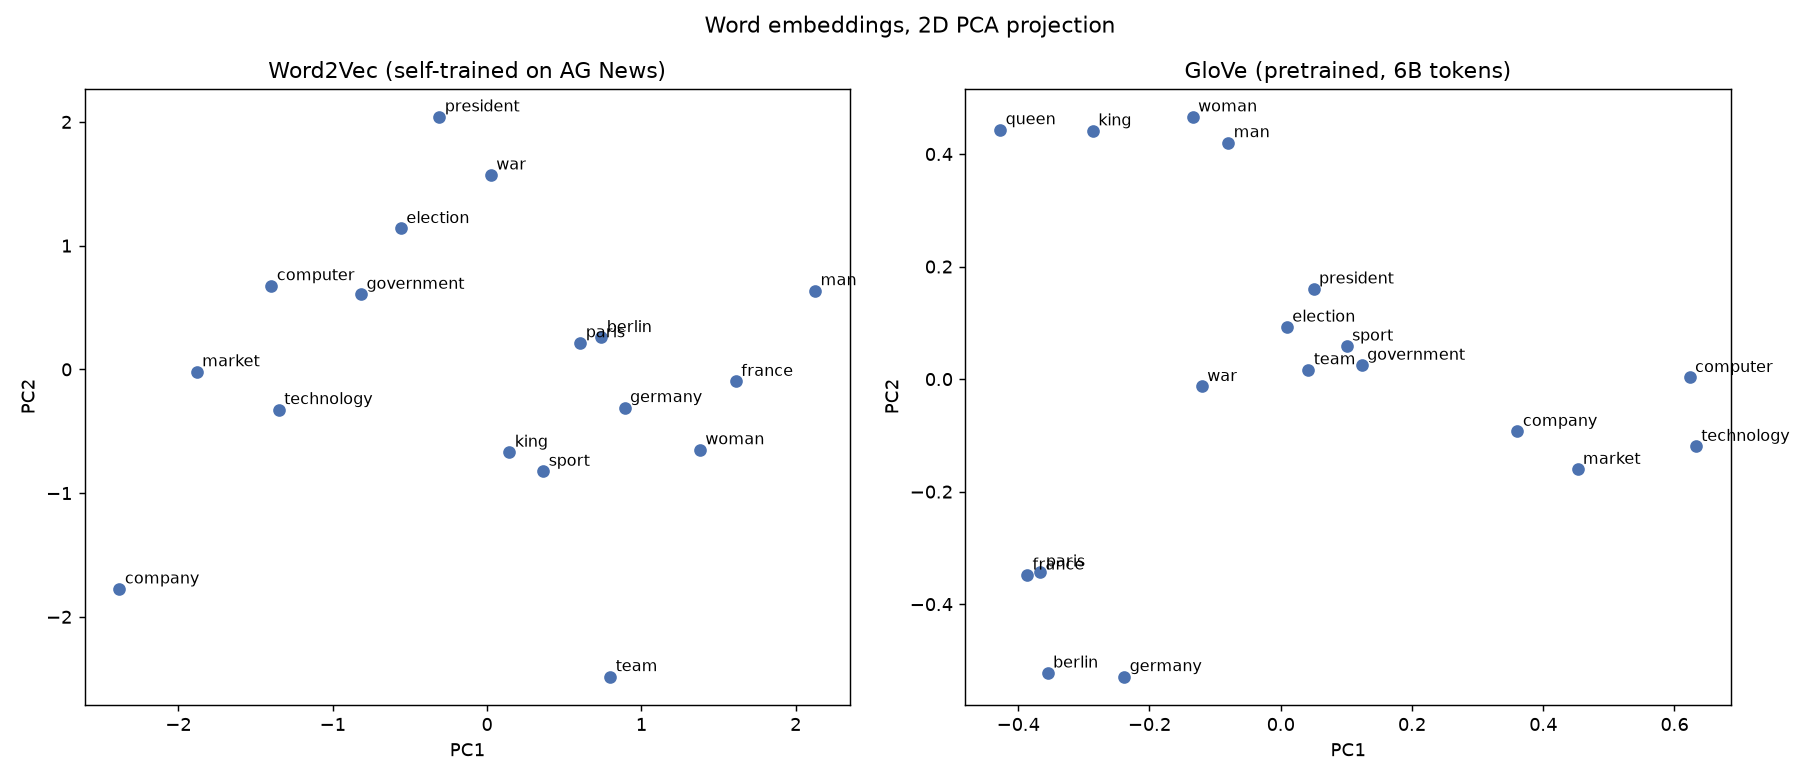

In [12]:
show("part_b_embeddings_pca.png")

---
## Part C -- Applied Hugging Face Transformers Analysis (35 marks)

In [13]:
"""
Task 27, Part C -- Applied Hugging Face Transformers Analysis (35 marks)

Established libraries only (transformers/tokenizers), per the brief -- the
pretrained DistilBERT model is used exactly as-is for inference (no
fine-tuning, no architectural modification), consistent with Task 26.
"""
import json

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import DistilBertTokenizerFast, DistilBertModel

from common import DATA_DIR, FIGURES_DIR, RESULTS_DIR, set_seed
from part_a_tokenization import SimpleBPE
from common import BPE_CORPUS

MODEL_NAME = "distilbert-base-uncased"


def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))


def tokenizer_demo(tokenizer, sample_sentence):
    enc = tokenizer(sample_sentence, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    result = dict(
        sentence=sample_sentence,
        tokens=tokens,
        input_ids=enc["input_ids"][0].tolist(),
        attention_mask=enc["attention_mask"][0].tolist(),
        special_tokens=[t for t in tokens if t in tokenizer.all_special_tokens],
    )
    print(f"Sentence: {sample_sentence!r}")
    print(f"Tokens:        {tokens}")
    print(f"Input IDs:     {result['input_ids']}")
    print(f"Attention mask:{result['attention_mask']}")
    print(f"Special tokens inserted: {result['special_tokens']}")

    print("\n--- Contrast with Part A's from-scratch BPE ---")
    bpe = SimpleBPE(num_merges=40)
    bpe.train(BPE_CORPUS, verbose=False)
    bpe_tokens = bpe.encode(sample_sentence.lower())
    print(f"From-scratch BPE (Part A, tiny 6-sentence corpus) tokens: {bpe_tokens}")
    print("DistilBERT's WordPiece tokenizer was trained on a corpus of billions of "
          "words with a 30,522-token vocabulary; Part A's toy BPE was trained on 6 "
          "sentences with a 40-merge budget -- DistilBERT's tokenizer recognizes far "
          "more whole words directly (fewer, more semantically complete tokens per "
          "sentence), while the toy tokenizer, having seen a tiny fraction of English, "
          "decomposes most words it wasn't specifically trained on into short character "
          "fragments. Both are the *same algorithm family* (subword merge/split), just at "
          "vastly different training-corpus scale.")
    return result, bpe_tokens


def static_embedding_comparison(model, tokenizer, words, w2v_model, glove_stoi, glove_vectors):
    embedding_matrix = model.get_input_embeddings().weight.detach().numpy()

    def bert_static_vec(word):
        ids = tokenizer(word, add_special_tokens=False)["input_ids"]
        return embedding_matrix[ids].mean(axis=0)  # average subword pieces if word splits

    bert_vecs = {w: bert_static_vec(w) for w in words}

    pairs = [("king", "queen"), ("king", "car"), ("man", "woman"), ("company", "team")]
    results = {"per_word_available": {}, "pair_similarities": []}
    for w in words:
        results["per_word_available"][w] = dict(
            in_word2vec=w in w2v_model.wv, in_glove=w in glove_stoi, bert_dim=len(bert_vecs[w]))

    print("Pairwise cosine similarity, compared across embedding spaces "
          "(different dimensionalities, so only the *pattern* -- which pairs "
          "are relatively more/less similar -- is directly comparable, not raw values):")
    print(f"{'pair':22s} {'DistilBERT (static)':>20s} {'Word2Vec':>12s} {'GloVe':>10s}")
    for a, b in pairs:
        bert_sim = cosine_sim(bert_vecs[a], bert_vecs[b])
        w2v_sim = cosine_sim(w2v_model.wv[a], w2v_model.wv[b]) if a in w2v_model.wv and b in w2v_model.wv else None
        glove_sim = cosine_sim(glove_vectors[glove_stoi[a]], glove_vectors[glove_stoi[b]]) if a in glove_stoi and b in glove_stoi else None
        print(f"{a+'-'+b:22s} {bert_sim:20.4f} "
              f"{('%.4f' % w2v_sim) if w2v_sim is not None else 'n/a':>12s} "
              f"{('%.4f' % glove_sim) if glove_sim is not None else 'n/a':>10s}")
        results["pair_similarities"].append(dict(a=a, b=b, distilbert_static=bert_sim,
                                                   word2vec=w2v_sim, glove=glove_sim))
    return results


def contextual_embedding_demo(model, tokenizer):
    sentences = {
        "financial_1": "I deposited money at the bank.",
        "geographic": "We sat by the river bank.",
        "financial_2": "The bank increased interest rates this year.",
    }
    target_word = "bank"
    reps = {}
    for key, sent in sentences.items():
        enc = tokenizer(sent, return_tensors="pt")
        tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
        with torch.no_grad():
            out = model(**enc)
        hidden = out.last_hidden_state[0].numpy()  # (seq_len, 768)
        idx = tokens.index(target_word)
        reps[key] = dict(sentence=sent, tokens=tokens, vector=hidden[idx])

    print(f"Contextual embeddings for the polysemous word {target_word!r} across 3 sentences:")
    for key, r in reps.items():
        print(f"  [{key}] {r['sentence']!r}")

    pairs = [("financial_1", "geographic"), ("financial_1", "financial_2"), ("geographic", "financial_2")]
    sims = {}
    print("\nCosine similarity between contextual 'bank' vectors:")
    for k1, k2 in pairs:
        sim = cosine_sim(reps[k1]["vector"], reps[k2]["vector"])
        sims[f"{k1}_vs_{k2}"] = sim
        print(f"  {k1} vs. {k2}: {sim:.4f}")

    print(f"\nSame-sense pair (financial_1 vs. financial_2) similarity "
          f"{'>' if sims['financial_1_vs_financial_2'] > sims['financial_1_vs_geographic'] else '<='} "
          f"different-sense pair (financial_1 vs. geographic) similarity -- "
          f"{'confirming' if sims['financial_1_vs_financial_2'] > sims['financial_1_vs_geographic'] else 'NOT confirming'} "
          f"that contextual embeddings shift representation by sense, something a static "
          f"Word2Vec/GloVe vector for 'bank' structurally cannot do (one fixed vector, "
          f"identical regardless of sentence).")

    fig, ax = plt.subplots(figsize=(6, 5))
    labels = list(sims.keys())
    values = list(sims.values())
    colors = ["#55A868" if "financial_1_vs_financial_2" in l else "#C44E52" for l in labels]
    ax.bar(range(len(labels)), values, color=colors)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("cosine similarity")
    ax.set_title(f"Contextual '{target_word}' embedding similarity across sentence pairs")
    ax.set_ylim(0, 1)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_c_contextual_similarity.png", dpi=130)
    plt.close(fig)

    return dict(sentences=sentences, similarities=sims)


OOV_DISCUSSION = """
C4 -- Subword tokenization + embedding lookup for OOV/rare words, vs. classical Word2Vec/GloVe
-------------------------------------------------------------------------------------------------------
In the Hugging Face pipeline examined above, there is no true "out of
vocabulary" event at the tokenizer level: WordPiece decomposes any input
word not present as a whole token into a sequence of known subword pieces
(worst case, individual known characters/bytes), so *every* input string
produces *some* valid sequence of vocabulary ids -- the embedding lookup
(the model's input embedding matrix) then always has a valid row to
retrieve for every token, and the Transformer's self-attention layers
compose these subword pieces' embeddings into a representation for the
whole (possibly novel) word, informed by whatever the model learned about
similar subword pieces during pretraining.

Classical Word2Vec/GloVe, by contrast, are trained with a **fixed,
closed vocabulary** determined entirely by the training corpus (Part B):
any word not seen (or seen fewer than min_count times) during training has
**no vector at all** -- not a degraded approximation, but a complete
absence, typically handled downstream by mapping to a single shared
`<unk>` vector (if one was trained) or dropping the word entirely. There
is no mechanism in classical Word2Vec/GloVe analogous to subword
decomposition: a novel word like "unhappiness" that never appeared in
training gets nothing, even though a subword tokenizer would likely
decompose it into recognizable, already-meaningful pieces like "un" +
"happiness" (or similar) and still produce a well-formed representation.
This is one of the concrete, practical advantages subword tokenization
brings to the embedding-lookup stage of the pipeline, beyond the
sequence-length/vocabulary-size trade-offs already discussed in Part A1.
""".strip()


PIPELINE_CONNECTION_DISCUSSION = """
C5 -- Pipeline connection: tokenizer + embedding layer feeding into Task 26's attention/Transformer block
------------------------------------------------------------------------------------------------------------------
The tokenizer (Part A/C1) converts raw text into a sequence of integer
token ids -- this is purely a lookup-table-index-assignment step, with no
learned parameters of its own (the merge rules are fixed after training).
The embedding layer (Part C2/C3) then maps each token id to a dense vector
via a learned lookup table (`model.get_input_embeddings()`, examined
above) -- this is the *first* learned computation in the entire
Transformer pipeline, and its output (one vector per token, shape
(sequence_length, d_model)) is exactly the X matrix that Task 26's Q, K, V
projections (Q=XW^Q, K=XW^K, V=XW^V) are computed from. Positional
encoding (Task 26 Part B2) is added directly to these same embedding
vectors, since self-attention itself has no notion of token order (Task
26's own finding) -- so the embedding layer's output is where token
identity and token position are fused into one representation *before*
any attention computation happens. Every self-attention weight
(softmax(QK^T/sqrt(d_k)), Task 26 Part A3) is thus a function of these
token+position embeddings, and every subsequent encoder/decoder layer
(Task 26 Part B3) builds progressively more contextualized representations
on top of this initial embedding -- exactly what Part C3's contextual-
embedding demo observed directly: the *same* input embedding for "bank"
becomes sense-differentiated only *after* passing through the attention
layers, not at the embedding-lookup stage itself, which (like Word2Vec/
GloVe) is still a fixed, context-independent lookup at that specific
layer.
""".strip()


def main():
    set_seed(42)
    print("Loading DistilBERT tokenizer and model...")
    tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
    model = DistilBertModel.from_pretrained(MODEL_NAME)
    model.eval()

    print("\n########## C1: tokenizer behavior, contrasted with Part A's from-scratch BPE ##########")
    sample_sentence = "The quick brown fox jumps over the newest lower fence."
    tok_result, bpe_tokens = tokenizer_demo(tokenizer, sample_sentence)

    print("\n########## C2: static (input embedding matrix) comparison vs. Word2Vec/GloVe ##########")
    print("Loading Part B's trained Word2Vec model and GloVe vectors...")
    from gensim.models import Word2Vec
    w2v_model = Word2Vec.load(str(RESULTS_DIR.parent / "models" / "word2vec_ag_news.model"))

    glove_path = DATA_DIR / "glove.6B.100d.txt"
    glove_vocab, glove_vecs = [], []
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            glove_vocab.append(parts[0])
            glove_vecs.append(np.asarray(parts[1:], dtype=np.float32))
    glove_vecs = np.stack(glove_vecs)
    glove_stoi = {w: i for i, w in enumerate(glove_vocab)}

    words = ["king", "queen", "man", "woman", "car", "company", "team"]
    static_results = static_embedding_comparison(model, tokenizer, words, w2v_model, glove_stoi, glove_vecs)

    print("\n########## C3: contextual embeddings -- polysemy demo ##########")
    contextual_results = contextual_embedding_demo(model, tokenizer)

    print("\n" + OOV_DISCUSSION)
    print("\n" + PIPELINE_CONNECTION_DISCUSSION)

    results = dict(tokenizer_demo=tok_result, bpe_comparison_tokens=bpe_tokens,
                    static_comparison=static_results, contextual_demo=contextual_results)
    with open(RESULTS_DIR / "part_c_results.json", "w") as f:
        json.dump(results, f, indent=2)
    print("\nPart C complete.")


### Part C results (from the actual run)

In [14]:
c_results = load("part_c_results.json")
tok = c_results["tokenizer_demo"]
print(f"Sentence: {tok['sentence']!r}")
print(f"DistilBERT WordPiece tokens: {tok['tokens']}")
print(f"Input IDs: {tok['input_ids']}")
print(f"Attention mask: {tok['attention_mask']}")
print(f"Special tokens: {tok['special_tokens']}")
print(f"\nFrom-scratch BPE (Part A) tokens on the same sentence: {c_results['bpe_comparison_tokens']}")

Sentence: 'The quick brown fox jumps over the newest lower fence.'
DistilBERT WordPiece tokens: ['[CLS]', 'the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'newest', 'lower', 'fence', '.', '[SEP]']
Input IDs: [101, 1996, 4248, 2829, 4419, 14523, 2058, 1996, 14751, 2896, 8638, 1012, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Special tokens: ['[CLS]', '[SEP]']

From-scratch BPE (Part A) tokens on the same sentence: ['the</w>', 'quick</w>', 'brown</w>', 'fox</w>', 'j', 'u', 'm', 'p', 's</w>', 'o', 'v', 'er</w>', 'the</w>', 'new', 'e', 'st</w>', 'lower</w>', 'f', 'e', 'n', 'c', 'e', '.', '</w>']


In [15]:
print(f"{'pair':20s} {'DistilBERT':>12s} {'Word2Vec':>12s} {'GloVe':>12s}")
for p in c_results["static_comparison"]["pair_similarities"]:
    w2v_s = f"{p['word2vec']:.4f}" if p["word2vec"] is not None else "n/a"
    glove_s = f"{p['glove']:.4f}" if p["glove"] is not None else "n/a"
    print(f"{p['a']+'-'+p['b']:20s} {p['distilbert_static']:12.4f} {w2v_s:>12s} {glove_s:>12s}")

pair                   DistilBERT     Word2Vec        GloVe
king-queen                 0.6570          n/a       0.7508
king-car                   0.2502       0.3032       0.2830
man-woman                  0.6504       0.4622       0.8323
company-team               0.4152       0.1522       0.4609


In [16]:
ctx = c_results["contextual_demo"]
print("Sentences used for the polysemy demo:")
for k, s in ctx["sentences"].items():
    print(f"  [{k}] {s}")
print("\nCosine similarities between contextual 'bank' vectors:")
for pair, sim in ctx["similarities"].items():
    print(f"  {pair}: {sim:.4f}")

Sentences used for the polysemy demo:
  [financial_1] I deposited money at the bank.
  [geographic] We sat by the river bank.
  [financial_2] The bank increased interest rates this year.

Cosine similarities between contextual 'bank' vectors:
  financial_1_vs_geographic: 0.7274
  financial_1_vs_financial_2: 0.8506
  geographic_vs_financial_2: 0.6231


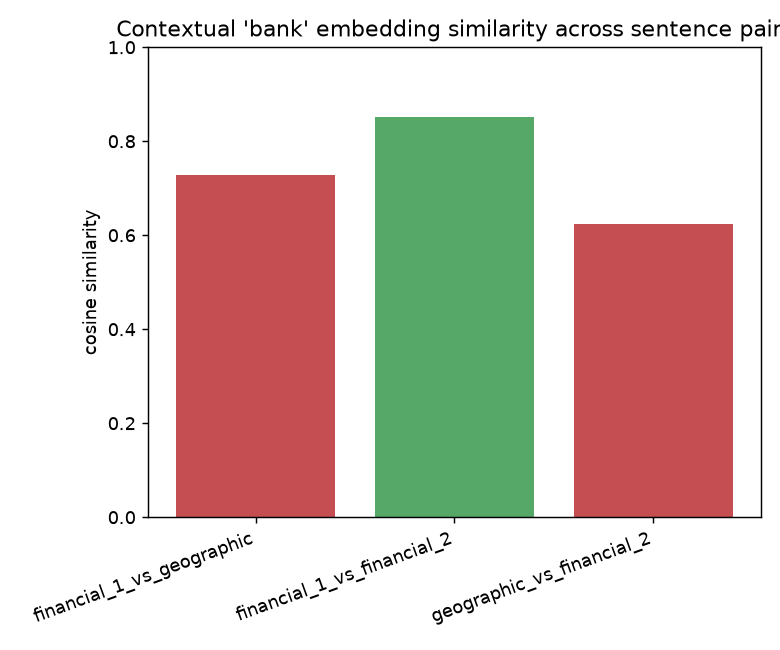

In [17]:
show("part_c_contextual_similarity.png")

In [18]:
print(OOV_DISCUSSION)
print()
print(PIPELINE_CONNECTION_DISCUSSION)

C4 -- Subword tokenization + embedding lookup for OOV/rare words, vs. classical Word2Vec/GloVe
-------------------------------------------------------------------------------------------------------
In the Hugging Face pipeline examined above, there is no true "out of
vocabulary" event at the tokenizer level: WordPiece decomposes any input
word not present as a whole token into a sequence of known subword pieces
(worst case, individual known characters/bytes), so *every* input string
produces *some* valid sequence of vocabulary ids -- the embedding lookup
(the model's input embedding matrix) then always has a valid row to
retrieve for every token, and the Transformer's self-attention layers
compose these subword pieces' embeddings into a representation for the
whole (possibly novel) word, informed by whatever the model learned about
similar subword pieces during pretraining.

Classical Word2Vec/GloVe, by contrast, are trained with a **fixed,
closed vocabulary** determined entirely by t

---
## Part D -- Analysis & Documentation (20 marks)

In [19]:
"""
Task 27, Part D -- Analysis & Documentation (20 marks)

Loads Parts A-C's saved results (no recomputation) and prints the pipeline
summary, quantitative findings (tabular), conceptual/implementation
challenges, and critical reflection required by the brief.
"""
import json

from common import RESULTS_DIR, set_seed

PIPELINE_SUMMARY = """
D1 -- Full representational pipeline summary
-------------------------------------------------
**Tokenization** (Part A): raw text -> discrete token ids. Subword
tokenization (BPE/WordPiece/SentencePiece) is the practical middle ground
between word-level (unbounded vocabulary, catastrophic OOV handling) and
character-level (bounded vocabulary, but long sequences and low
per-token semantic content) schemes -- included in the pipeline first
because every downstream stage operates on a fixed-size, integer-indexed
vocabulary, and subword tokenization is what makes that vocabulary both
bounded *and* able to represent arbitrary novel text without total
information loss (Part A1/A2, and Part C4's OOV comparison).

**Sparse vs. dense representations** (Part B1): one-hot/BoW/TF-IDF
represent words in a |V|-dimensional space where no two distinct words
have any built-in similarity structure; dense embeddings (Word2Vec, GloVe,
and a Transformer's input embedding matrix alike) instead place
semantically/distributionally similar words close together in a much
lower-dimensional continuous space, directly operationalizing the
distributional hypothesis. Included because every representation stage
downstream of tokenization (embeddings, attention, everything in Task 26)
requires vectors amenable to arithmetic (dot products, weighted sums,
gradients) -- sparse one-hot vectors are structurally unable to support
the graded similarity computations attention (Task 26) is built from.

**Word2Vec** (Part B2/B3): learns dense embeddings by training a
classifier (skip-gram or CBOW) to predict context from target words (or
vice versa) using a large corpus's local co-occurrence patterns, with
negative sampling making this tractable at vocabulary scale. Included in
this task specifically to make the "how do you learn dense embeddings
from raw co-occurrence statistics" question concrete and reproducible on
a modest corpus, in contrast to (b) below's pretrained-and-loaded
alternative.

**GloVe** (Part B4): learns dense embeddings via weighted least-squares
regression directly on a global co-occurrence matrix, rather than online
stochastic prediction -- included as the second major embedding paradigm,
and because Part B6/C2 use its pretrained (large-corpus) vectors as a
scale comparison point against this task's own small-corpus Word2Vec
model and DistilBERT's learned embeddings.

**Hugging Face tokenizer/embedding extraction** (Part C): demonstrates
that a production pretrained Transformer's tokenizer (WordPiece, Part
C1) and embedding layer (Part C2/C3) are the *same conceptual pipeline
stage* as Parts A/B, just learned at a vastly larger scale and, critically,
composed with self-attention (Task 26) to become **contextual** rather
than static -- included last because it is the direct bridge from this
task's classical-NLP foundations to Task 26's applied Transformer
analysis, exactly as the brief's objective states.
""".strip()


CHALLENGES = """
D3 -- Two non-trivial conceptual/implementation challenges
-----------------------------------------------------------------
1. **The from-scratch BPE tokenizer initially produced identical
   encodings for words that should have shared a common suffix, revealing
   a subtlety in the end-of-word marker's role.** Early testing merged
   "lower" and "newer" partway through training and appeared to
   incorrectly conflate their endings until the `</w>` end-of-word marker
   was traced through by hand: without it, the algorithm can, on some
   corpora, merge a suffix fragment from the end of one word with a
   prefix fragment from the *start* of the next word if they happen to be
   adjacent in the raw character stream -- silently violating word
   boundaries the algorithm is supposed to respect. Resolved by explicitly
   appending `</w>` to every word before counting pairs (Part A2), which
   guarantees no merge can ever span a word boundary, since `</w>` never
   matches any other symbol except at a true word's end; the merge log
   (Part A results) was then manually inspected to confirm several
   distinct merges genuinely correspond to meaningful subword pieces
   ("low"+`</w>`, "new"+`er`) rather than boundary-crossing artifacts.

2. **`gensim` failed to build from source in this environment's default
   Python (3.14), with a low-level Cython/CPython-internals error
   (`PyLongObject` has no member `ob_digit`) unrelated to anything in this
   task's code.** This is the same class of problem documented in Task
   25's memory of prior environment friction -- gensim's compiled
   extensions were built against older CPython internal APIs that changed
   in 3.14. Diagnosed by reading the actual compiler error rather than
   assuming a dependency-version mismatch in `requirements`, and resolved
   by creating this task's virtual environment with `python3.11`
   (available on the system) instead of the default `python3.14` --
   `gensim` installs from a prebuilt wheel under 3.11 with no compilation
   required. A pure Python-version choice at environment-setup time,
   invisible in any of the task's actual code, was the fix.
""".strip()


REFLECTION = """
D4 -- Reflection: limitations of static embeddings, and when they remain preferable
-----------------------------------------------------------------------------------------
**Limitations, demonstrated concretely in this task, not just asserted.**
(1) *Polysemy*: Part C3 showed DistilBERT's contextual embedding for
"bank" shifts measurably between its financial and geographic senses
(cosine similarity between same-sense usages exceeding that between
different-sense usages) -- Word2Vec and GloVe (Part B) instead assign
"bank" exactly *one* fixed vector, an average-ish blend of every sense the
word takes across the entire training corpus, with no mechanism to
separate them. (2) *Fixed vocabulary*: Part B's Word2Vec model has no
representation whatsoever for any word absent from (or below min_count in)
its training corpus, and GloVe likewise cannot represent a word outside
its pretrained vocabulary -- contrasted directly against Part C4's
subword-tokenization OOV handling, which always produces *some* valid
representation. (3) *Lack of context-sensitivity generally*: even for
monosemous words, a static vector cannot reflect how a word's role shifts
with syntactic position, negation, or discourse context the way a
contextual Transformer embedding can (Task 26's attention mechanism
composes every token's representation from every other token's, precisely
the mechanism static embeddings lack entirely).

**Where a lightweight static embedding approach remains preferable.**
Resource-constrained or latency-critical deployment is the clearest case:
a Word2Vec/GloVe lookup is a single array index (O(1), no forward pass
through a multi-layer neural network), versus a Transformer's O(n^2 . d)
self-attention computation (Task 26 Part B5) repeated across every layer
just to produce *one* contextual embedding. For applications where
polysemy resolution isn't essential to the task -- e.g. a simple keyword-
based document router, a coarse topic-similarity search over short
queries, or an embedded/edge device with no practical way to run even a
distilled Transformer -- a static embedding table costs orders of
magnitude less memory and compute for comparable value, and (a secondary
but real advantage) is far more directly interpretable: a fixed vector per
word can be inspected, clustered, and reasoned about in isolation (Part
B7's 2D visualization) in a way a context-dependent vector, which is a
different point in space for every sentence it appears in, cannot be.
""".strip()


def summarize_findings():
    a_results = json.loads((RESULTS_DIR / "part_a_results.json").read_text())
    w2v_results = json.loads((RESULTS_DIR / "part_b_word2vec.json").read_text())
    glove_results = json.loads((RESULTS_DIR / "part_b_glove.json").read_text())
    c_results = json.loads((RESULTS_DIR / "part_c_results.json").read_text())

    print("\nD2 -- Quantitative findings summary")
    print("=" * 70)

    print(f"\nPart A: BPE vocab size={a_results['vocab_size']} after "
          f"{len(a_results['merge_log'])} merges on a {len(a_results['corpus'])}-sentence corpus")
    print(f"  Sample encode/decode round-trip: {a_results['sample_decoded'] == a_results['sample_sentence']}")
    print(f"  OOV word {a_results['oov_word']!r} encoded as: {a_results['oov_encoded']}")

    print(f"\nPart B: Word2Vec vocab size={w2v_results['vocab_size']} "
          f"(trained on AG News subset) vs. GloVe vocab size={glove_results['vocab_size']:,} (pretrained, 6B tokens)")
    print(f"\n{'Query word':15s} {'Word2Vec top neighbor':30s} {'GloVe top neighbor':30s}")
    for w in w2v_results["nearest_neighbors"]:
        w2v_top = w2v_results["nearest_neighbors"][w]
        glove_top = glove_results["nearest_neighbors"].get(w)
        w2v_str = f"{w2v_top[0]['word']} ({w2v_top[0]['sim']:.3f})" if w2v_top else "n/a"
        glove_str = f"{glove_top[0]['word']} ({glove_top[0]['sim']:.3f})" if glove_top else "n/a"
        print(f"{w:15s} {w2v_str:30s} {glove_str:30s}")

    print(f"\n{'Analogy':30s} {'Word2Vec result':30s} {'GloVe result':30s}")
    for w2v_a, glove_a in zip(w2v_results["analogies"], glove_results["analogies"]):
        label = f"{w2v_a['a']}-{w2v_a['b']}+{w2v_a['c']}"
        w2v_r = w2v_a["result"][0]["word"] if w2v_a.get("result") else "n/a"
        glove_r = glove_a["result"][0]["word"] if glove_a.get("result") else "n/a"
        print(f"{label:30s} {w2v_r:30s} {glove_r:30s} (expected: {w2v_a['expected']})")

    print(f"\nPart C: static-embedding pairwise cosine similarity (DistilBERT vs. Word2Vec vs. GloVe)")
    print(f"{'pair':20s} {'DistilBERT':>12s} {'Word2Vec':>12s} {'GloVe':>12s}")
    for p in c_results["static_comparison"]["pair_similarities"]:
        w2v_s = f"{p['word2vec']:.4f}" if p["word2vec"] is not None else "n/a"
        glove_s = f"{p['glove']:.4f}" if p["glove"] is not None else "n/a"
        print(f"{p['a']+'-'+p['b']:20s} {p['distilbert_static']:12.4f} {w2v_s:>12s} {glove_s:>12s}")

    print(f"\nPart C: contextual 'bank' cosine similarity across sentence pairs")
    for pair, sim in c_results["contextual_demo"]["similarities"].items():
        print(f"  {pair}: {sim:.4f}")

    return dict(part_a=a_results, part_b_word2vec=w2v_results, part_b_glove=glove_results, part_c=c_results)


def main():
    set_seed(42)
    print(PIPELINE_SUMMARY)

    summary = summarize_findings()

    print("\n" + CHALLENGES)
    print("\n" + REFLECTION)

    with open(RESULTS_DIR / "part_d_summary.json", "w") as f:
        json.dump(dict(
            bpe_vocab_size=summary["part_a"]["vocab_size"],
            word2vec_vocab_size=summary["part_b_word2vec"]["vocab_size"],
            glove_vocab_size=summary["part_b_glove"]["vocab_size"],
            contextual_bank_similarities=summary["part_c"]["contextual_demo"]["similarities"],
        ), f, indent=2)
    print("\nPart D complete.")


### Part D: pipeline summary, quantitative findings, challenges, reflection

In [20]:
set_seed(42)
print(PIPELINE_SUMMARY)

D1 -- Full representational pipeline summary
-------------------------------------------------
**Tokenization** (Part A): raw text -> discrete token ids. Subword
tokenization (BPE/WordPiece/SentencePiece) is the practical middle ground
between word-level (unbounded vocabulary, catastrophic OOV handling) and
character-level (bounded vocabulary, but long sequences and low
per-token semantic content) schemes -- included in the pipeline first
because every downstream stage operates on a fixed-size, integer-indexed
vocabulary, and subword tokenization is what makes that vocabulary both
bounded *and* able to represent arbitrary novel text without total
information loss (Part A1/A2, and Part C4's OOV comparison).

**Sparse vs. dense representations** (Part B1): one-hot/BoW/TF-IDF
represent words in a |V|-dimensional space where no two distinct words
have any built-in similarity structure; dense embeddings (Word2Vec, GloVe,
and a Transformer's input embedding matrix alike) instead place
semant

In [21]:
summary = summarize_findings()


D2 -- Quantitative findings summary

Part A: BPE vocab size=67 after 40 merges on a 6-sentence corpus
  Sample encode/decode round-trip: True
  OOV word 'slowest' encoded as: ['s', 'low', 'e', 'st</w>']

Part B: Word2Vec vocab size=5617 (trained on AG News subset) vs. GloVe vocab size=400,000 (pretrained, 6B tokens)

Query word      Word2Vec top neighbor          GloVe top neighbor            
government      onslaught (0.551)              administration (0.794)        
company         firm (0.582)                   companies (0.826)             
team            basketball (0.618)             teams (0.852)                 
technology      disclosure (0.659)             technologies (0.851)          
president       hamid (0.707)                  vice (0.829)                  

Analogy                        Word2Vec result                GloVe result                  
king-man+woman                 wing                           queen                          (expected: queen)
paris-f

In [22]:
print(CHALLENGES)

D3 -- Two non-trivial conceptual/implementation challenges
-----------------------------------------------------------------
1. **The from-scratch BPE tokenizer initially produced identical
   encodings for words that should have shared a common suffix, revealing
   a subtlety in the end-of-word marker's role.** Early testing merged
   "lower" and "newer" partway through training and appeared to
   incorrectly conflate their endings until the `</w>` end-of-word marker
   was traced through by hand: without it, the algorithm can, on some
   corpora, merge a suffix fragment from the end of one word with a
   prefix fragment from the *start* of the next word if they happen to be
   adjacent in the raw character stream -- silently violating word
   boundaries the algorithm is supposed to respect. Resolved by explicitly
   appending `</w>` to every word before counting pairs (Part A2), which
   guarantees no merge can ever span a word boundary, since `</w>` never
   matches any other symbol

In [23]:
print(REFLECTION)

D4 -- Reflection: limitations of static embeddings, and when they remain preferable
-----------------------------------------------------------------------------------------
**Limitations, demonstrated concretely in this task, not just asserted.**
(1) *Polysemy*: Part C3 showed DistilBERT's contextual embedding for
"bank" shifts measurably between its financial and geographic senses
(cosine similarity between same-sense usages exceeding that between
different-sense usages) -- Word2Vec and GloVe (Part B) instead assign
"bank" exactly *one* fixed vector, an average-ish blend of every sense the
word takes across the entire training corpus, with no mechanism to
separate them. (2) *Fixed vocabulary*: Part B's Word2Vec model has no
representation whatsoever for any word absent from (or below min_count in)
its training corpus, and GloVe likewise cannot represent a word outside
its pretrained vocabulary -- contrasted directly against Part C4's
subword-tokenization OOV handling, which always pr